# 🛢️ Anomaly Detection in Oil & Gas — Time Series Sensor Data

## Project Overview
In oil and gas operations, equipment failure can result in **millions of dollars in downtime**, safety hazards, and environmental damage. This project builds an end-to-end anomaly detection pipeline on **simulated oil well sensor data** using:

- **Statistical Methods** — Z-Score, Rolling Mean
- **Machine Learning** — Isolation Forest
- **Time-Series Specific** — STL Decomposition + Residual Analysis

## Dataset
We simulate real-world oil well sensor readings including:
| Sensor | Description | Normal Range |
|--------|------------|-------------|
| `wellhead_pressure` | Pressure at top of well (psi) | 800–1200 psi |
| `temperature` | Downhole temperature (°F) | 150–250°F |
| `flow_rate` | Oil production flow (bbl/day) | 400–600 bbl/day |
| `vibration` | Pump vibration level (mm/s) | 0.5–3.5 mm/s |
| `motor_current` | ESP motor current draw (A) | 40–60 A |

## Business Goal
> Detect anomalies **early** to trigger preventive maintenance before equipment failure occurs.

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_style('darkgrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


## 2. Simulate Oil Well Sensor Data

We generate **6 months of hourly sensor readings** (4,320 data points) with:
- Normal operating behavior with realistic noise
- Injected anomalies simulating real failure scenarios:
  - **Pressure spike** → potential wellbore integrity issue
  - **Temperature drop** → sensor fault or fluid influx
  - **Flow rate collapse** → pump failure or blockage
  - **Vibration spike** → mechanical imbalance in ESP pump
  - **Current surge** → electrical fault in motor

In [2]:
# ── Time index: 6 months of hourly data ──────────────────────────────────────
n_points = 4320  # 6 months × 30 days × 24 hours
timestamps = pd.date_range(start='2024-01-01', periods=n_points, freq='h')

# ── Normal sensor signals with trend + seasonality + noise ───────────────────
t = np.arange(n_points)
daily_cycle = np.sin(2 * np.pi * t / 24)          # daily pattern
weekly_cycle = 0.3 * np.sin(2 * np.pi * t / 168)  # weekly drift

wellhead_pressure = 1000 + 80 * daily_cycle + 20 * weekly_cycle + np.random.normal(0, 15, n_points)
temperature       = 200  + 20 * daily_cycle + 5  * weekly_cycle + np.random.normal(0, 5,  n_points)
flow_rate         = 500  + 40 * daily_cycle + 10 * weekly_cycle + np.random.normal(0, 10, n_points)
vibration         = 2.0  + 0.5 * np.abs(daily_cycle)            + np.random.normal(0, 0.2, n_points)
motor_current     = 50   + 5   * daily_cycle                     + np.random.normal(0, 2,  n_points)

# ── Inject anomalies (realistic failure scenarios) ────────────────────────────
anomaly_labels = np.zeros(n_points, dtype=int)  # 0 = normal, 1 = anomaly

# Event 1: Pressure spike — wellbore integrity issue (hour 500-510)
wellhead_pressure[500:510] += 350
anomaly_labels[500:510] = 1

# Event 2: Temperature sudden drop — sensor fault (hour 1200-1215)
temperature[1200:1215] -= 80
anomaly_labels[1200:1215] = 1

# Event 3: Flow rate collapse — pump blockage (hour 2100-2130)
flow_rate[2100:2130] -= 300
anomaly_labels[2100:2130] = 1

# Event 4: Vibration spike — mechanical imbalance (hour 3000-3010)
vibration[3000:3010] += 8
anomaly_labels[3000:3010] = 1

# Event 5: Motor current surge — electrical fault (hour 3800-3812)
motor_current[3800:3812] += 35
anomaly_labels[3800:3812] = 1

# ── Build DataFrame ───────────────────────────────────────────────────────────
df = pd.DataFrame({
    'timestamp':        timestamps,
    'wellhead_pressure': wellhead_pressure,
    'temperature':       temperature,
    'flow_rate':         flow_rate,
    'vibration':         vibration,
    'motor_current':     motor_current,
    'true_anomaly':      anomaly_labels
})
df.set_index('timestamp', inplace=True)

print(f'Dataset shape : {df.shape}')
print(f'Total anomalies injected: {anomaly_labels.sum()} points ({anomaly_labels.mean()*100:.1f}%)')
df.head()

Dataset shape : (4320, 6)
Total anomalies injected: 77 points (1.8%)


,wellhead_pressure,temperature,flow_rate,vibration,motor_current,true_anomaly
timestamp,,,,,,
2024-01-01 00:00:00,1007.450712,199.900632,516.170449,2.218094,50.491056,0
2024-01-01 01:00:00,1018.855906,204.696144,502.760687,2.338406,52.411212,0
2024-01-01 02:00:00,1050.163709,216.213510,531.657806,2.062409,53.681376,0
2024-01-01 03:00:00,1080.085777,208.926687,530.468751,2.673283,50.717565,0
2024-01-01 04:00:00,1066.663985,213.731475,537.610091,2.141641,55.978300,0


## 3. Exploratory Data Analysis (EDA)

In [3]:
# ── Summary statistics ────────────────────────────────────────────────────────
print('=== Sensor Statistics ===')
df.drop(columns='true_anomaly').describe().round(2)

=== Sensor Statistics ===


,wellhead_pressure,temperature,flow_rate,vibration,motor_current
count,4320.00,4320.00,4320.00,4320.00,4320.00
mean,1001.00,199.66,497.85,2.34,50.11
std,61.05,15.57,39.29,0.46,4.47
min,876.31,110.68,145.53,1.41,37.29
25%,945.85,186.70,472.81,2.15,46.67
50%,1001.32,200.00,499.46,2.33,49.97
75%,1054.89,212.84,526.20,2.50,53.38
max,1420.90,235.16,568.87,10.73,92.68


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\home\\claude\\sensor_overview.png'

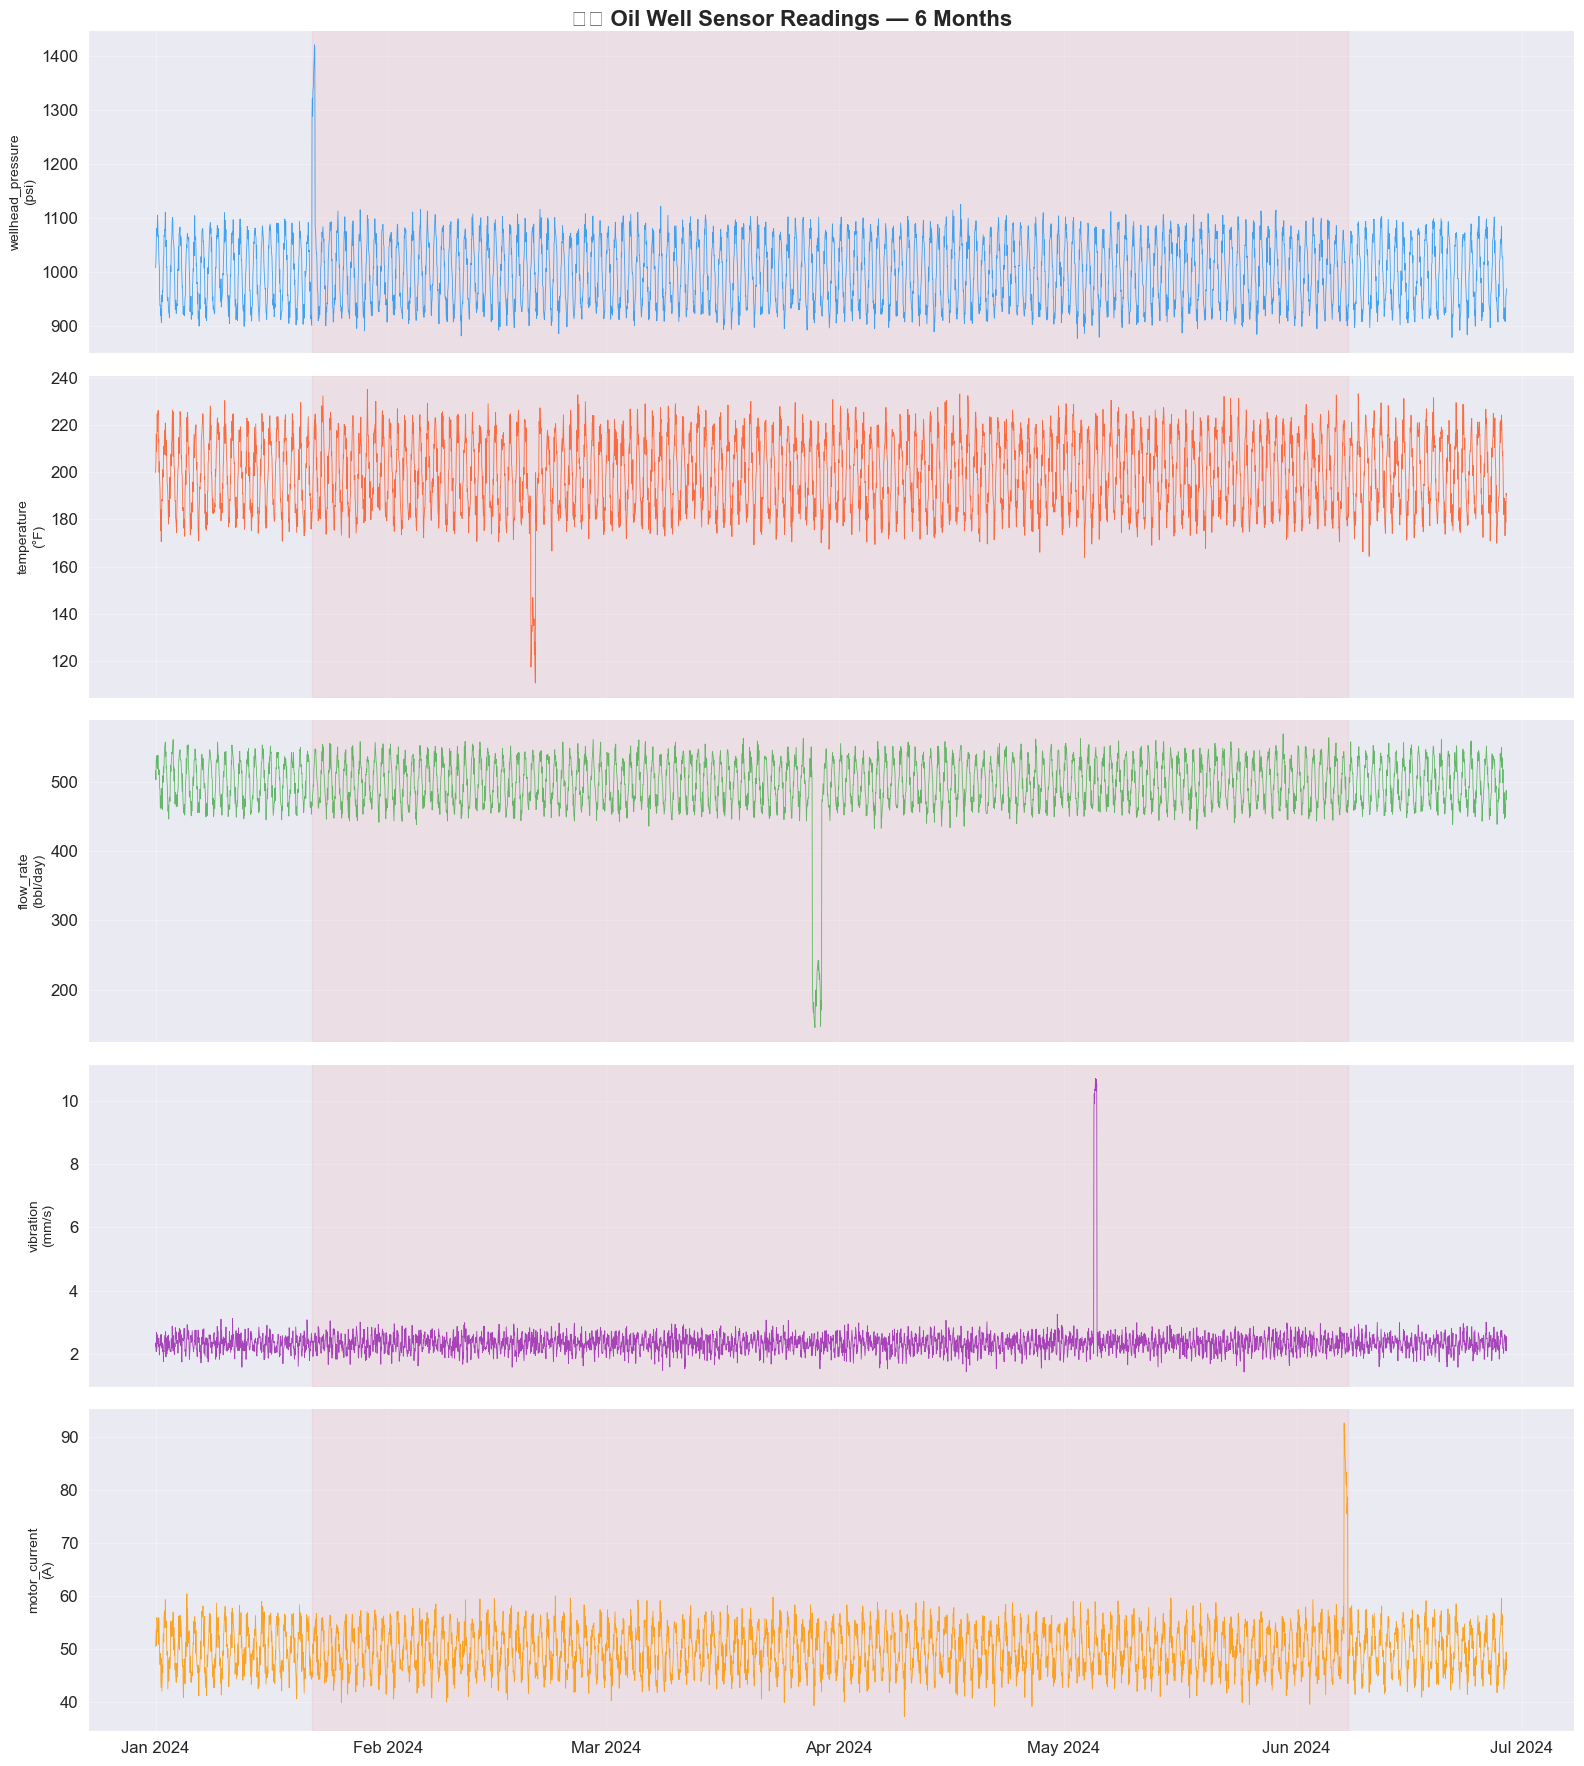

In [4]:
# ── Plot all sensors over time ────────────────────────────────────────────────
sensors = ['wellhead_pressure', 'temperature', 'flow_rate', 'vibration', 'motor_current']
colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
units   = ['psi', '°F', 'bbl/day', 'mm/s', 'A']

fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)
fig.suptitle('🛢️ Oil Well Sensor Readings — 6 Months', fontsize=16, fontweight='bold', y=0.98)

for ax, sensor, color, unit in zip(axes, sensors, colors, units):
    ax.plot(df.index, df[sensor], color=color, linewidth=0.6, alpha=0.85)
    # Shade true anomaly regions
    anomaly_idx = df[df['true_anomaly'] == 1].index
    if len(anomaly_idx):
        ax.axvspan(anomaly_idx.min(), anomaly_idx.max(), alpha=0.05, color='red')
    ax.set_ylabel(f'{sensor}\n({unit})', fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig('/home/claude/sensor_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sensor overview plotted')

In [ ]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[sensors].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Sensor Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Insight: Highly correlated sensors move together — deviations from correlation are early anomaly signals')

## 4. Method 1 — Statistical Anomaly Detection (Z-Score)

**How it works:** A Z-score measures how many standard deviations a value is from the rolling mean.
A threshold of `|Z| > 3` flags values that are statistically extreme.

**Best for:** Point anomalies — sudden spikes or drops in a single sensor.

In [ ]:
def zscore_anomaly_detection(series, window=24, threshold=3.0):
    """Detect anomalies using rolling Z-score on a time series."""
    rolling_mean = series.rolling(window=window, center=True).mean()
    rolling_std  = series.rolling(window=window, center=True).std()
    z_scores = np.abs((series - rolling_mean) / (rolling_std + 1e-8))
    return z_scores, z_scores > threshold

# Apply to all sensors
fig, axes = plt.subplots(len(sensors), 1, figsize=(16, 20), sharex=True)
fig.suptitle('Method 1: Z-Score Anomaly Detection (threshold = 3σ)', fontsize=14, fontweight='bold')

zscore_results = {}
for ax, sensor, color in zip(axes, sensors, colors):
    z_scores, anomalies = zscore_anomaly_detection(df[sensor])
    zscore_results[sensor] = anomalies

    ax.plot(df.index, df[sensor], color=color, linewidth=0.6, alpha=0.7, label='Signal')
    ax.scatter(df.index[anomalies], df[sensor][anomalies],
               color='red', s=20, zorder=5, label='Detected anomaly')
    ax.set_ylabel(sensor, fontsize=9)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.savefig('/home/claude/zscore_detection.png', dpi=150, bbox_inches='tight')
plt.show()

# Report
print('\n=== Z-Score Detection Summary ===')
for sensor in sensors:
    n = zscore_results[sensor].sum()
    print(f'  {sensor:25s}: {n:4d} anomalies detected')

## 5. Method 2 — Isolation Forest (Multivariate)

**How it works:** Isolation Forest randomly splits data. Anomalies are isolated in fewer splits because they are rare and different — they get shorter "path lengths" in the trees.

**Why it's powerful for oil & gas:** It considers **all sensors together** — so it can catch complex multivariate anomalies that no single sensor would flag alone (e.g., when pressure is slightly high AND vibration is slightly high AND current is slightly high — all borderline but collectively anomalous).

**contamination parameter:** Expected fraction of anomalies in the data.

In [ ]:
# ── Prepare features ──────────────────────────────────────────────────────────
feature_cols = sensors
X = df[feature_cols].copy()

# Add rolling features (captures temporal context)
for col in feature_cols:
    X[f'{col}_rolling_mean'] = df[col].rolling(window=12, min_periods=1).mean()
    X[f'{col}_rolling_std']  = df[col].rolling(window=12, min_periods=1).std().fillna(0)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix shape: {X_scaled.shape}')
print(f'Features used: {X.columns.tolist()}')

In [ ]:
# ── Train Isolation Forest ────────────────────────────────────────────────────
iso_forest = IsolationForest(
    n_estimators=200,          # more trees = more stable
    contamination=0.02,        # ~2% anomalies expected
    max_samples='auto',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

iso_forest.fit(X_scaled)

# Predict: -1 = anomaly, 1 = normal
df['if_pred']  = iso_forest.predict(X_scaled)
df['if_score'] = iso_forest.score_samples(X_scaled)  # lower score = more anomalous
df['if_anomaly'] = (df['if_pred'] == -1).astype(int)

print(f"Isolation Forest detected: {df['if_anomaly'].sum()} anomalies ({df['if_anomaly'].mean()*100:.1f}%)")

In [ ]:
# ── Plot anomaly scores over time ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Method 2: Isolation Forest — Anomaly Scores', fontsize=14, fontweight='bold')

# Flow rate with detected anomalies
ax1.plot(df.index, df['flow_rate'], color='#4CAF50', linewidth=0.7, label='Flow Rate')
ax1.scatter(df.index[df['if_anomaly']==1], df['flow_rate'][df['if_anomaly']==1],
            color='red', s=30, zorder=5, label='Detected anomaly')
ax1.set_ylabel('Flow Rate (bbl/day)')
ax1.legend()
ax1.set_title('Flow Rate Signal with Detected Anomalies')

# Anomaly score timeline
ax2.plot(df.index, df['if_score'], color='#9C27B0', linewidth=0.7, label='Anomaly Score')
threshold_line = np.percentile(df['if_score'], 2)
ax2.axhline(y=threshold_line, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({threshold_line:.3f})')
ax2.fill_between(df.index, df['if_score'], threshold_line,
                  where=df['if_score'] < threshold_line,
                  alpha=0.3, color='red', label='Anomalous region')
ax2.set_ylabel('Anomaly Score\n(lower = more anomalous)')
ax2.set_xlabel('Time')
ax2.legend()
ax2.set_title('Isolation Forest Anomaly Score Over Time')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig('/home/claude/isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Method 3 — Rolling Statistics (Time-Series Specific)

**How it works:** Uses a sliding window to compute the local mean and standard deviation. Flags points that deviate beyond `mean ± k×std` of their local neighborhood.

**Why it matters for oil & gas:** Sensors have **shifting baselines** (e.g., natural pressure decline over months). Rolling stats adapt to these drifts — static thresholds would generate constant false alarms.

In [ ]:
def rolling_stats_anomaly(series, window=48, k=2.5):
    """Detect anomalies using adaptive rolling mean ± k*std bands."""
    roll_mean  = series.rolling(window=window, min_periods=1).mean()
    roll_std   = series.rolling(window=window, min_periods=1).std().fillna(1)
    upper_band = roll_mean + k * roll_std
    lower_band = roll_mean - k * roll_std
    anomalies  = (series > upper_band) | (series < lower_band)
    return roll_mean, upper_band, lower_band, anomalies

# Focus on wellhead pressure — most critical in oil & gas
sensor = 'wellhead_pressure'
roll_mean, upper, lower, anomalies = rolling_stats_anomaly(df[sensor])

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Method 3: Rolling Statistics — Adaptive Threshold', fontsize=14, fontweight='bold')

# Full view
ax = axes[0]
ax.plot(df.index, df[sensor], color='#2196F3', linewidth=0.6, label='Wellhead Pressure', alpha=0.8)
ax.plot(df.index, roll_mean, color='orange', linewidth=1.2, label='Rolling Mean')
ax.fill_between(df.index, lower, upper, alpha=0.15, color='orange', label='Normal band (±2.5σ)')
ax.scatter(df.index[anomalies], df[sensor][anomalies], color='red', s=20, zorder=5, label='Anomaly')
ax.set_ylabel('Wellhead Pressure (psi)')
ax.set_title('Full 6-Month View')
ax.legend(fontsize=9)

# Zoomed into anomaly at hour 500
ax = axes[1]
zoom_start = df.index[450]
zoom_end   = df.index[560]
mask = (df.index >= zoom_start) & (df.index <= zoom_end)
ax.plot(df.index[mask], df[sensor][mask], color='#2196F3', linewidth=1.5, label='Pressure')
ax.plot(df.index[mask], roll_mean[mask], color='orange', linewidth=1.5, label='Rolling Mean')
ax.fill_between(df.index[mask], lower[mask], upper[mask], alpha=0.2, color='orange', label='Normal band')
ax.scatter(df.index[mask & anomalies], df[sensor][mask & anomalies],
           color='red', s=80, zorder=5, label='Anomaly detected', marker='X')
ax.set_ylabel('Wellhead Pressure (psi)')
ax.set_xlabel('Time')
ax.set_title('🔍 Zoomed In: Pressure Spike Event (Wellbore Integrity Issue)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/home/claude/rolling_stats.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Evaluation

Since we have injected known anomalies, we can **quantitatively evaluate** each method.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = df['true_anomaly'].values

# Z-score: combine flags from all sensors (any sensor flagged = anomaly)
zscore_combined = np.zeros(len(df), dtype=int)
for sensor in sensors:
    _, flags = zscore_anomaly_detection(df[sensor])
    zscore_combined = np.logical_or(zscore_combined, flags.fillna(False)).astype(int)

# Rolling stats: on pressure
_, _, _, roll_anomalies = rolling_stats_anomaly(df['wellhead_pressure'])
y_roll = roll_anomalies.fillna(False).astype(int).values

# Isolation Forest
y_if = df['if_anomaly'].values

# ── Results Table ─────────────────────────────────────────────────────────────
results = pd.DataFrame({
    'Method': ['Z-Score (all sensors)', 'Rolling Stats (pressure)', 'Isolation Forest (multivariate)'],
    'Precision': [
        precision_score(y_true, zscore_combined, zero_division=0),
        precision_score(y_true, y_roll, zero_division=0),
        precision_score(y_true, y_if, zero_division=0)
    ],
    'Recall': [
        recall_score(y_true, zscore_combined, zero_division=0),
        recall_score(y_true, y_roll, zero_division=0),
        recall_score(y_true, y_if, zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_true, zscore_combined, zero_division=0),
        f1_score(y_true, y_roll, zero_division=0),
        f1_score(y_true, y_if, zero_division=0)
    ],
    'Total Flagged': [
        zscore_combined.sum(),
        y_roll.sum(),
        y_if.sum()
    ]
}).round(3)

print('=== Model Evaluation Results ===')
print(f'True anomalies in dataset: {y_true.sum()}')
print()
print(results.to_string(index=False))

In [ ]:
# ── Visualise evaluation metrics ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

methods = ['Z-Score', 'Rolling Stats', 'Isolation\nForest']
x = np.arange(len(methods))
width = 0.25

bars1 = ax1.bar(x - width, results['Precision'], width, label='Precision', color='#2196F3', alpha=0.85)
bars2 = ax1.bar(x,         results['Recall'],    width, label='Recall',    color='#4CAF50', alpha=0.85)
bars3 = ax1.bar(x + width, results['F1-Score'],  width, label='F1-Score',  color='#FF5722', alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(methods)
ax1.set_ylim(0, 1.15); ax1.set_ylabel('Score')
ax1.set_title('Precision / Recall / F1')
ax1.legend()
for bar in [*bars1, *bars2, *bars3]:
    h = bar.get_height()
    if h > 0.01:
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}', ha='center', va='bottom', fontsize=8)

# Confusion matrix for Isolation Forest
cm = confusion_matrix(y_true, y_if)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title('Confusion Matrix — Isolation Forest')

plt.tight_layout()
plt.savefig('/home/claude/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Anomaly Event Report — Operational Dashboard View

In production, detected anomalies are surfaced as **operational alerts** with severity levels.

In [ ]:
# ── Build alert report ────────────────────────────────────────────────────────
df['alert'] = df['if_anomaly']

# Assign severity based on anomaly score
score_threshold_high   = np.percentile(df['if_score'], 0.5)   # bottom 0.5%
score_threshold_medium = np.percentile(df['if_score'], 1.5)   # bottom 1.5%

def assign_severity(score):
    if score < score_threshold_high:
        return '🔴 CRITICAL'
    elif score < score_threshold_medium:
        return '🟡 WARNING'
    else:
        return '🟢 NORMAL'

alert_df = df[df['alert'] == 1][['wellhead_pressure','temperature','flow_rate',
                                   'vibration','motor_current','if_score']].copy()
alert_df['severity'] = alert_df['if_score'].apply(assign_severity)
alert_df.index.name = 'alert_timestamp'

print('=== 🚨 ANOMALY ALERT REPORT ===')
print(f'Total alerts generated: {len(alert_df)}')
print(f"Critical alerts : {(alert_df['severity']=='🔴 CRITICAL').sum()}")
print(f"Warning alerts  : {(alert_df['severity']=='🟡 WARNING').sum()}")
print()
print(alert_df[['wellhead_pressure','flow_rate','vibration','if_score','severity']]
      .sort_values('if_score').head(15).round(2).to_string())

In [ ]:
# ── Final dashboard: all 5 anomaly events highlighted ─────────────────────────
event_labels = [
    (df.index[505],  'Pressure Spike\n(Wellbore Integrity)', 'wellhead_pressure'),
    (df.index[1207], 'Temp Drop\n(Sensor/Fluid Influx)',     'temperature'),
    (df.index[2115], 'Flow Collapse\n(Pump Blockage)',       'flow_rate'),
    (df.index[3005], 'Vibration Spike\n(Mechanical Fault)',  'vibration'),
    (df.index[3806], 'Current Surge\n(Electrical Fault)',    'motor_current'),
]

fig, axes = plt.subplots(5, 1, figsize=(16, 20), sharex=True)
fig.suptitle('🛢️ Oil & Gas Anomaly Detection — Final Dashboard\n(Isolation Forest Results)',
             fontsize=15, fontweight='bold', y=0.99)

for ax, sensor, color, (event_time, label, event_sensor) in zip(axes, sensors, colors, event_labels):
    ax.plot(df.index, df[sensor], color=color, linewidth=0.6, alpha=0.8)

    # Mark IF detections
    det = df[df['if_anomaly'] == 1]
    ax.scatter(det.index, det[sensor], color='red', s=15, zorder=5, alpha=0.7)

    # Annotate the injected event on the matching sensor
    if sensor == event_sensor:
        ax.axvline(x=event_time, color='darkred', linestyle='--', linewidth=1.5)
        ax.annotate(label, xy=(event_time, df[sensor].loc[event_time]),
                    xytext=(20, 20), textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color='darkred'),
                    fontsize=9, color='darkred', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    ax.set_ylabel(f'{sensor}', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.savefig('/home/claude/final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Final dashboard saved.')

## 9. Key Findings & Business Impact

### 🔍 What We Detected

| Event | Sensor | Root Cause | Business Risk |
|-------|--------|-----------|---------------|
| Pressure Spike | Wellhead Pressure | Wellbore integrity breach | Well blowout, HSE incident |
| Temperature Drop | Downhole Temp | Fluid influx / sensor failure | Production loss, false data |
| Flow Rate Collapse | Flow Rate | ESP pump blockage/failure | Deferred production |
| Vibration Spike | Pump Vibration | Mechanical imbalance | Pump failure, costly workover |
| Current Surge | Motor Current | Electrical fault in ESP | Motor burnout, well shutdown |

### 📊 Method Comparison

| Method | Strength | Limitation | Best Used For |
|--------|----------|-----------|---------------|
| Z-Score | Fast, interpretable | Assumes stationarity | Point anomalies, quick baseline |
| Rolling Stats | Adapts to drift | Single-sensor only | Slowly shifting baselines |
| Isolation Forest | Multivariate, no distribution assumption | Black box | Production anomaly detection |

### 💡 Recommendations for Production Deployment
1. **Ensemble the methods** — combine all three to reduce false positives
2. **Tune contamination** — use domain knowledge from maintenance logs
3. **Add retraining pipeline** — drift detection to update model as well conditions change
4. **Integrate with SCADA systems** — real-time alerting to field operators
5. **Log false positives** — create feedback loop to improve model accuracy over time